# EDA exploratoire sur les features Gold — distributions, non-renseigné, gravité par sous-groupe

Contrairement à `eda_baseline_baac.ipynb` (qui évalue un modèle et n'a qu'une EDA minimale :
taux de gravité par année + un comptage de NULL SQL qui manque la sentinelle BAAC), ce notebook
fait de la vraie analyse exploratoire visuelle, sur les données Gold déjà nettoyées/typées
plutôt que sur les CSV bruts — ce qui évite l'erreur trouvée en auditant `eda_baseline_baac` :
dans Gold, le code BAAC `-1` (« non renseigné ») est une valeur entière normale, pas un NULL
SQL, donc on peut le compter correctement sans reproduire le nettoyage déjà fait par
`gravia.silver`/`gravia.gold`.

Complément : `eda_raw_baac.ipynb` fait la même vérification sur le **brut** (avant nettoyage),
ce qui a permis de trouver et corriger deux bugs réels dans `gravia.silver`/`gravia.gold`.

Nécessite la stack dev démarrée (PostgreSQL, Gold déjà chargé — cf. `python -m gravia.gold`).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import sqlalchemy as sa

from gravia.config import get_settings
from ml.features.gold_features import BASELINE_CATEGORICAL_COLUMNS, load_gold_features

In [2]:
# Exécuté avec le répertoire de travail à la racine du dépôt — nécessaire pour que `ml` soit
# importable (pas installé comme package, cf. pyproject.toml, contrairement à `gravia`).
OUTPUT_DIR = Path("notebooks/img")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#: Sous-ensemble de BASELINE_CATEGORICAL_COLUMNS réellement codé -1 = non renseigné dans Gold.
#: `departement` et `categorie_route`/`type_collision` sont soit toujours renseignés, soit déjà
#: décodés en libellé texte par Gold (cf. ml/features/gold_features.py, docstring) : pas de
#: sentinelle -1 numérique à y chercher.
SENTINEL_CODED_COLUMNS: tuple[str, ...] = tuple(
    c for c in BASELINE_CATEGORICAL_COLUMNS if c not in ("departement", "type_collision")
)

settings = get_settings()
engine = sa.create_engine(settings.database.url)
df = load_gold_features(engine)
print(f"Chargé : {df.height} accidents (Gold, 2019-2023)")

Chargé : 273226 accidents (Gold, 2019-2023)


## Taux de gravité par millésime

Vérifie la stabilité déjà citée en prose ailleurs (~35-36 % chaque année).

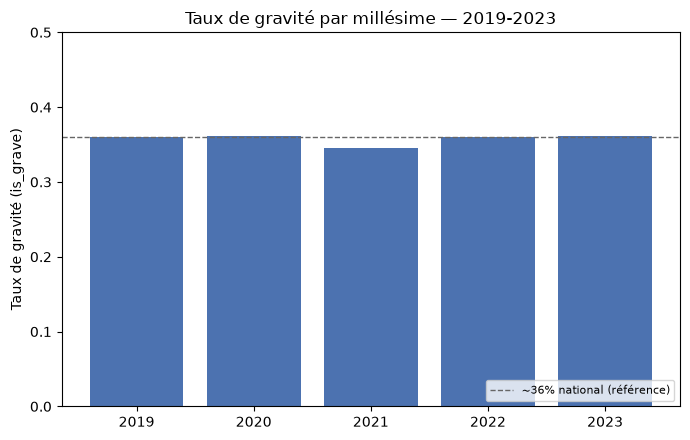

In [3]:
by_year = df.group_by("annee").agg(pl.col("is_grave").mean().alias("taux_grave")).sort("annee")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(by_year["annee"].cast(pl.Utf8), by_year["taux_grave"], color="#4C72B0")
ax.axhline(0.36, color="#666", linestyle="--", linewidth=1, label="~36% national (référence)")
ax.set_ylabel("Taux de gravité (is_grave)")
ax.set_title("Taux de gravité par millésime — 2019-2023")
ax.set_ylim(0, 0.5)
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_target_balance_by_year.png", dpi=150)
plt.show()

## Non-renseigné par feature catégorielle

Compte la sentinelle `-1` explicitement, pas les NULL SQL : dans Gold, une valeur `-1` est un
entier normal, jamais un NULL — un comptage `is_null()` renverrait silencieusement 0 % partout,
l'erreur trouvée dans `eda_baseline_baac`.

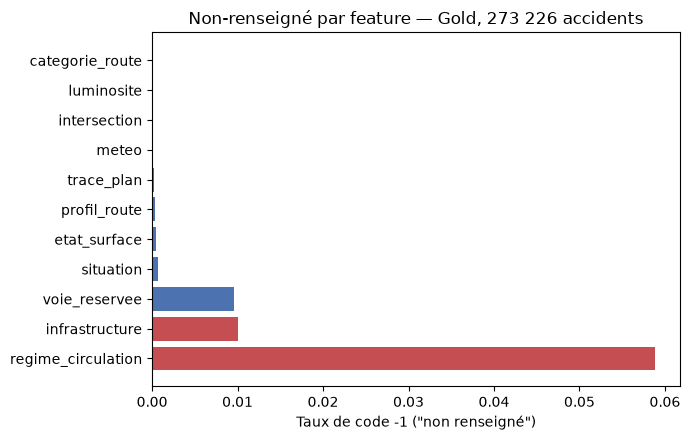

In [4]:
rates = {c: (df[c] == -1).mean() for c in SENTINEL_CODED_COLUMNS}
series = pl.Series(list(rates.values()))
order = series.arg_sort(descending=True)
labels = [list(rates.keys())[i] for i in order]
values = [list(rates.values())[i] for i in order]

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#C44E52" if v >= 0.01 else "#4C72B0" for v in values]
ax.barh(labels, values, color=colors)
ax.set_xlabel('Taux de code -1 ("non renseigné")')
ax.set_title("Non-renseigné par feature — Gold, 273 226 accidents")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_missingness.png", dpi=150)
plt.show()

`regime_circulation` culmine à 5,9 % — cohérent avec `eda_raw_sentinel_rate.png` (sur le brut).

## Taux de gravité par département

Intuition visuelle de l'hétérogénéité géographique développée dans l'angle mort du seuil
unique (Paris = département 75, cf. `eval_seuil_par_zone.ipynb`).

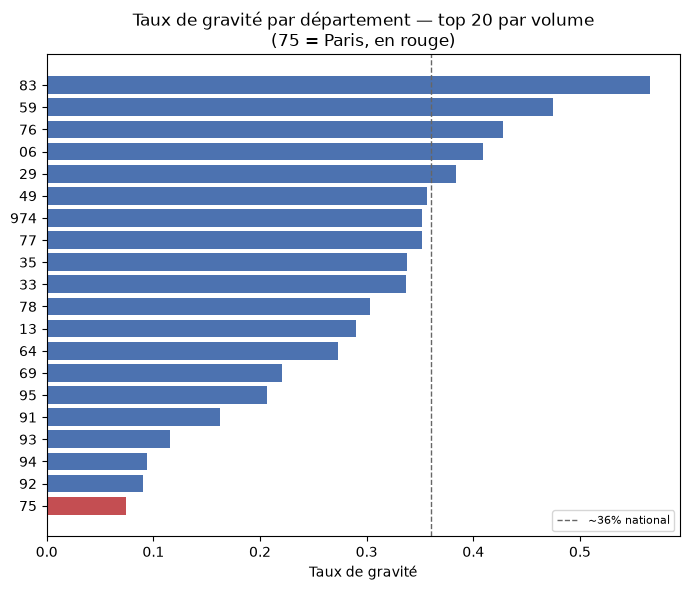

In [5]:
by_dep = (
    df.group_by("departement")
    .agg(pl.len().alias("n"), pl.col("is_grave").mean().alias("taux_grave"))
    .sort("n", descending=True)
    .head(20)
    .sort("taux_grave")
)

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#C44E52" if d == "75" else "#4C72B0" for d in by_dep["departement"]]
ax.barh(by_dep["departement"], by_dep["taux_grave"], color=colors)
ax.axvline(0.36, color="#666", linestyle="--", linewidth=1, label="~36% national")
ax.set_xlabel("Taux de gravité")
ax.set_title("Taux de gravité par département — top 20 par volume\n(75 = Paris, en rouge)")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_gravity_by_departement.png", dpi=150)
plt.show()

Paris est nettement sous la moyenne nationale — cette EDA donne déjà l'intuition de l'angle
mort du seuil unique, avant même d'entraîner un modèle.

## Taux de gravité par valeur, pour 3 features catégorielles

Vraie exploration bivariée, pas juste l'importance de feature d'un modèle déjà entraîné.

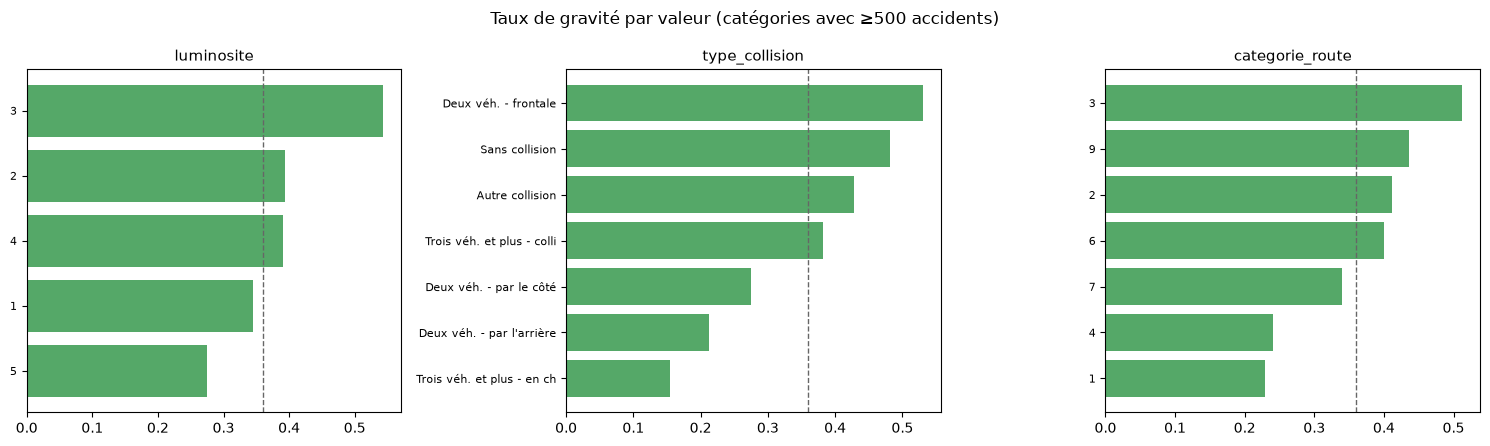

In [6]:
features = ["luminosite", "type_collision", "categorie_route"]
#: `type_collision` est décodé en libellé texte par Gold (cf. ml/features/gold_features.py) :
#: le non-renseigné y est la chaîne "Non renseigné", pas l'entier -1.
not_specified = {"type_collision": "Non renseigné"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, feature in zip(axes, features, strict=True):
    excluded = not_specified.get(feature, -1)
    by_value = (
        df.filter(pl.col(feature) != excluded)
        .group_by(feature)
        .agg(pl.len().alias("n"), pl.col("is_grave").mean().alias("taux_grave"))
        .filter(pl.col("n") >= 500)  # écarte les valeurs trop rares, taux instable
        .sort("taux_grave")
    )
    labels = [str(v).replace("véhicules", "véh.")[:26] for v in by_value[feature]]
    ax.barh(labels, by_value["taux_grave"], color="#55A868")
    ax.axvline(0.36, color="#666", linestyle="--", linewidth=1)
    ax.set_title(feature, fontsize=11)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Taux de gravité par valeur (catégories avec ≥500 accidents)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_gravity_by_feature.png", dpi=150)
plt.show()